In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

%matplotlib inline

(800, 600, 3)
(800, 1500, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

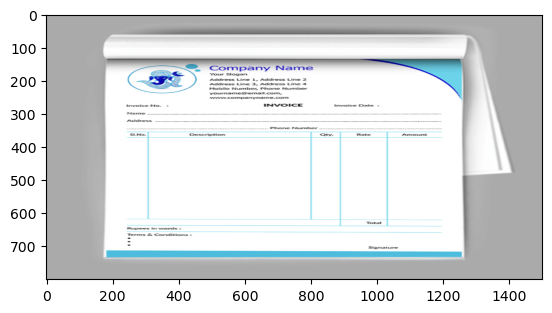

In [18]:
im_path =r"C:\Users\admin\Desktop\projects\bill-book-102-600x800.png"

img =cv2.imread(im_path)
print(img.shape)

#Resize the image
img = cv2.resize(img, (1500, 800))
print(img.shape)
#BGR TO 

plt.imshow(img)
plt.show


*Remove the Noise
*Edge Detection
*Contour Extraction
*Best Contour Selection
*Project to the Screen

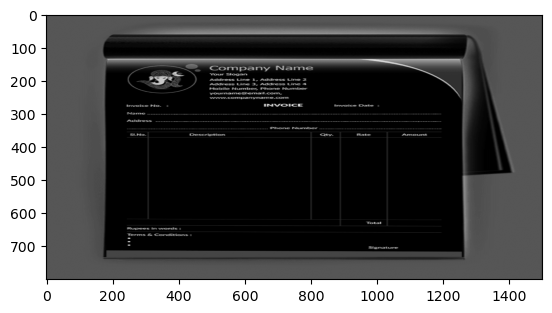

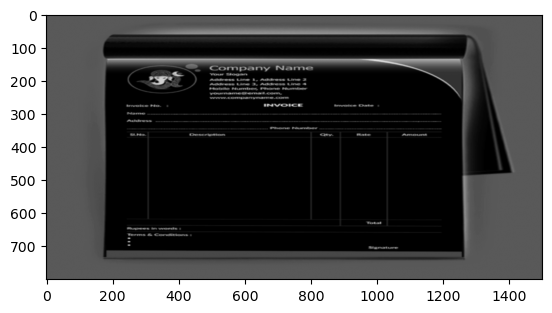

In [19]:
#Remove the Noise

##Blurring the image

orig = img.copy()
gray = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
plt.imshow(gray , cmap = "binary")
plt.show()

blurred = cv2.GaussianBlur(gray, (5,5) , 0)
plt.imshow(blurred , cmap = "binary")
plt.show()

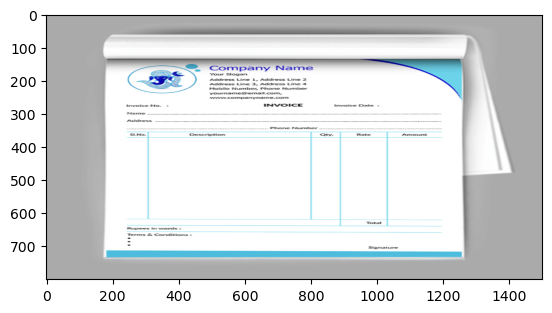

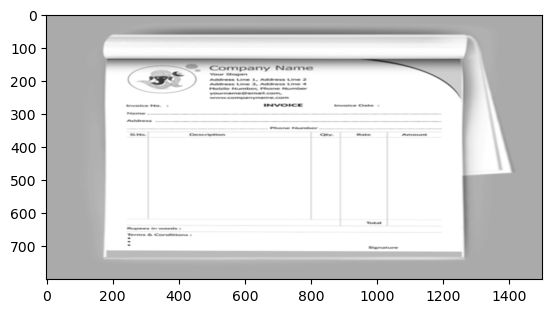

In [20]:
regen = cv2.cvtColor(blurred , cv2.COLOR_GRAY2BGR)
plt.imshow(orig)
plt.show()

plt.imshow(regen)
plt.show()

In [21]:
regen.shape


(800, 1500, 3)

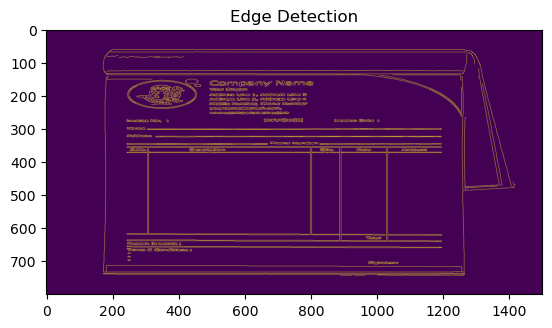

In [22]:
## Edge Detection
edge = cv2.Canny(blurred, 0, 50)
orig_edge = edge.copy()

plt.imshow(orig_edge)
plt.title("Edge Detection")
plt.show()

In [23]:
## Contour Extraction 
contours , _ = cv2.findContours(edge , cv2.RETR_LIST , cv2.CHAIN_APPROX_NONE)
print(len(contours))

contours = sorted(contours, reverse = True, key = cv2.contourArea)


852


In [24]:
## Select the best contour region

for c in contours:

    p = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.01*p, True)

    if len(approx) == 4 :
        target = approx
        break

print(target.shape)

    

(4, 1, 2)


In [25]:
## reorder the target contour

def reorder(h):
    h = h.reshape((4,2))
    print(h)

    hnew = np.zeros((4,2), dtype = np.float32)

    add = h.sum(axis = 1)
    hnew[3] = h[np.argmax(add)]
    hnew[1] = h[np.argmax(add)]

    diff = np.diff(h, axis = 1)
    hnew[0] = h[np.argmax(diff)]
    hnew[2] = h[np.argmax(diff)]

    return hnew

In [26]:
reorder = reorder(target)
print("********")
print(reorder)

[[ 892  357]
 [ 892  637]
 [1029  638]
 [1029  357]]
********
[[ 892.  637.]
 [1029.  638.]
 [ 892.  637.]
 [1029.  638.]]


In [27]:
## project to the fixed screen

input_representation = reorder 

output_map = np.float32([[0,0],[800,0],[800,800],[0,800]])


In [28]:
M = cv2.getPerspectiveTransform(input_representation, output_map)
ans = cv2.warpPerspective(orig, M, (800,800))

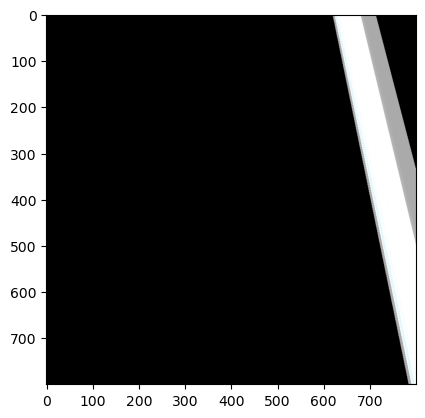

In [29]:
plt.imshow(ans)
plt.show()
